# EE446 - TinyML - Assignment 2

**Luke Valerio**

Programming questions 1-5. Each solution block is labelled with the
corresponding `[Pro]` problem number from the assignment handout.


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

# ---------------------------------------------------------------------------
# Reproducibility: every run of this notebook must produce the SAME train/test
# split. Question 5 hard-codes specific X_test rows into the Arduino sketch, so
# the split that trained the model has to be the split that generated those
# rows -- otherwise the .ino would be fed samples from a different shuffle.
# ---------------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Folder for the figures / reports that get embedded in the .pdf writeup.
import os
os.makedirs("writeup_assets", exist_ok=True)

print("TensorFlow :", tf.__version__)
print("Seed       :", SEED)


TensorFlow : 2.14.1
Seed       : 42


## Reading Data

In [2]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [3]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [4]:
# ===== Question 1(a): drop the four unused columns =====================
# 'land', 'urgent', 'numfailedlogins' and 'numoutboundcmds' are dropped.
# In this dataset these four are near-constant (almost every row is 0), so they
# carry essentially no discriminative information for the attack/normal task.

cols_to_drop = ['land', 'urgent', 'numfailedlogins', 'numoutboundcmds']

print("Shape before drop:", data.shape)
data = data.drop(columns=cols_to_drop)
print("Shape after  drop:", data.shape)
print("Dropped:", cols_to_drop)


Shape before drop: (125973, 43)
Shape after  drop: (125973, 39)
Dropped: ['land', 'urgent', 'numfailedlogins', 'numoutboundcmds']


##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [5]:
# ===== Question 1(b): collapse all attack types into a single 'attack' label ==
# The raw column holds 23 distinct values (normal, neptune, smurf, satan, ...).
# Everything that is not exactly 'normal' becomes 'attack', turning this into a
# binary classification problem.

print("Distinct labels BEFORE :", data['attack'].nunique())
print(data['attack'].value_counts().head(10), "\n")

data['attack'] = data['attack'].apply(lambda label: 'normal' if label == 'normal' else 'attack')

print("Distinct labels AFTER  :", data['attack'].nunique())
print(data['attack'].value_counts())


Distinct labels BEFORE : 23
attack
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64 

Distinct labels AFTER  : 2
attack
normal    67343
attack    58630
Name: count, dtype: int64


In [6]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [7]:
# ===== Question 1(c): LabelEncoder on the non-numerical columns ==============
# 'protocoltype', 'service' and 'flag' are categorical strings; 'attack' is the
# binary target. A separate LabelEncoder is fitted per column and kept in a dict
# so the mapping can be inspected/reused later.

categorical_cols = ['protocoltype', 'service', 'flag', 'attack']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    shown = dict(list(mapping.items())[:6])
    suffix = " ..." if len(mapping) > 6 else ""
    print(f"{col:14s} -> {len(mapping):2d} classes | {shown}{suffix}")

# LabelEncoder sorts alphabetically, so 'attack' < 'normal' gives attack=0,
# normal=1. This matches the comment in the feature-scaling cell below and is
# the convention used for the red/blue colouring in Question 2.
ATTACK_LABEL = int(encoders['attack'].transform(['attack'])[0])
NORMAL_LABEL = int(encoders['attack'].transform(['normal'])[0])
print(f"\nATTACK_LABEL = {ATTACK_LABEL}   NORMAL_LABEL = {NORMAL_LABEL}")
assert (ATTACK_LABEL, NORMAL_LABEL) == (0, 1)


protocoltype   ->  3 classes | {'icmp': 0, 'tcp': 1, 'udp': 2}
service        -> 70 classes | {'IRC': 0, 'X11': 1, 'Z39_50': 2, 'aol': 3, 'auth': 4, 'bgp': 5} ...
flag           -> 11 classes | {'OTH': 0, 'REJ': 1, 'RSTO': 2, 'RSTOS0': 3, 'RSTR': 4, 'S0': 5} ...
attack         ->  2 classes | {'attack': 0, 'normal': 1}

ATTACK_LABEL = 0   NORMAL_LABEL = 1


In [8]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [9]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
# NOTE: random_state=SEED added so the split is reproducible (see imports cell).
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, Y, test_size = 0.20, random_state = SEED, stratify = Y)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

N_FEATURES = X_train.shape[1]
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test :", X_test.shape,  " y_test :", y_test.shape)
print("Number of input features:", N_FEATURES, "(must match NUMBER_OF_INPUTS in network_data.ino)")


X_train: (100778, 38)  y_train: (100778, 1)
X_test : (25195, 38)  y_test : (25195, 1)
Number of input features: 38 (must match NUMBER_OF_INPUTS in network_data.ino)


## Question 2: Dimensionality Reduction for Visualization

In [10]:
# ===== Question 2: shared setup for the three 2-D visualisations ============
# X_test holds 25,194 samples. KernelPCA with an RBF kernel materialises a dense
# n x n kernel matrix -- 25,194^2 float64 entries is roughly 5 GB -- and t-SNE at
# that size runs for hours. A class-balanced (stratified) subsample of 5,000
# points is used instead, which preserves the structure of the data while
# keeping all three methods tractable. The SAME subsample feeds (a), (b) and (c)
# so the three plots are directly comparable.

VIZ_N = 5000

viz_idx, _ = train_test_split(
    np.arange(len(X_test)),
    train_size=VIZ_N,
    stratify=y_test.ravel(),
    random_state=SEED,
)

X_viz = X_test[viz_idx]
y_viz = y_test[viz_idx].ravel()

print(f"Visualising {len(X_viz)} of {len(X_test)} test samples "
      f"({100*len(X_viz)/len(X_test):.1f}% stratified subsample)")
print(f"  attack (label {ATTACK_LABEL}, red) : {(y_viz == ATTACK_LABEL).sum()}")
print(f"  normal (label {NORMAL_LABEL}, blue): {(y_viz == NORMAL_LABEL).sum()}")


def plot_2d(Z, y, title, filename):
    """Scatter a 2-D embedding: red = attack, blue = normal."""
    plt.figure(figsize=(9, 7))
    plt.scatter(Z[y == ATTACK_LABEL, 0], Z[y == ATTACK_LABEL, 1],
                c='red',  s=6, alpha=0.45, edgecolors='none', label='attack')
    plt.scatter(Z[y == NORMAL_LABEL, 0], Z[y == NORMAL_LABEL, 1],
                c='blue', s=6, alpha=0.45, edgecolors='none', label='normal')
    plt.title(title, fontsize=13)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    leg = plt.legend(markerscale=3, frameon=True)
    for handle in leg.legend_handles:
        handle.set_alpha(1.0)
    plt.grid(alpha=0.2, linestyle=':')
    plt.tight_layout()
    plt.savefig(join("writeup_assets", filename), dpi=150, bbox_inches='tight')
    plt.show()


Visualising 5000 of 25195 test samples (19.8% stratified subsample)
  attack (label 0, red) : 2327
  normal (label 1, blue): 2673


##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.000s...
[t-SNE] Computed neighbors for 5000 samples in 0.189s...


[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.097770


[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.630909


[t-SNE] KL divergence after 1000 iterations: 0.533292
t-SNE finished in 17.4 s


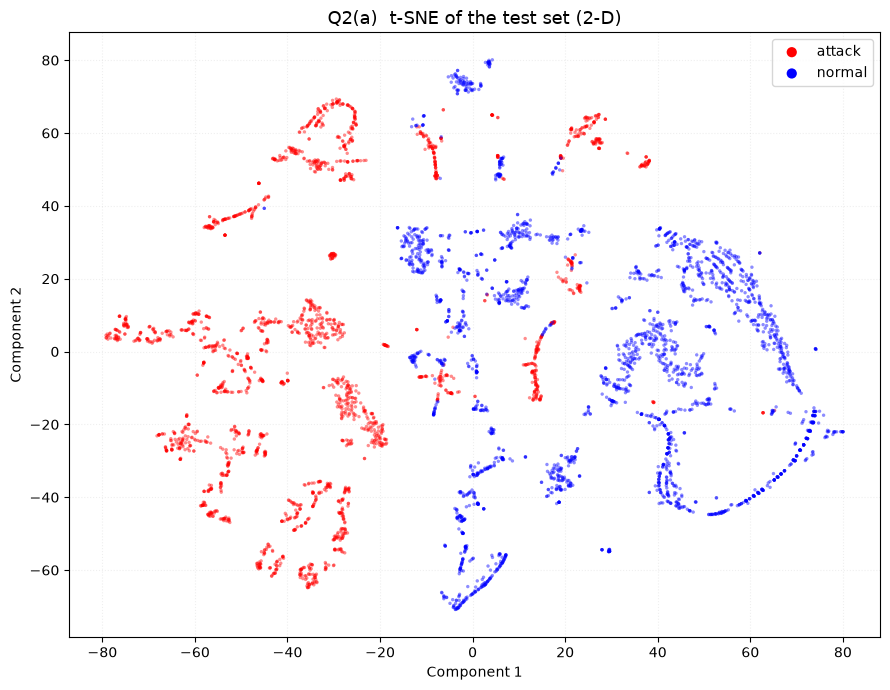

In [11]:
from sklearn.manifold import TSNE
# ===== Question 2(a): t-SNE ==================================================
import time

t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=SEED, verbose=1)
X_tsne = tsne.fit_transform(X_viz)
print(f"t-SNE finished in {time.time()-t0:.1f} s")

plot_2d(X_tsne, y_viz,
        "Q2(a)  t-SNE of the test set (2-D)",
        "q2a_tsne.png")


##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

Explained variance  PC1 = 0.2406   PC2 = 0.1578   total = 0.3984


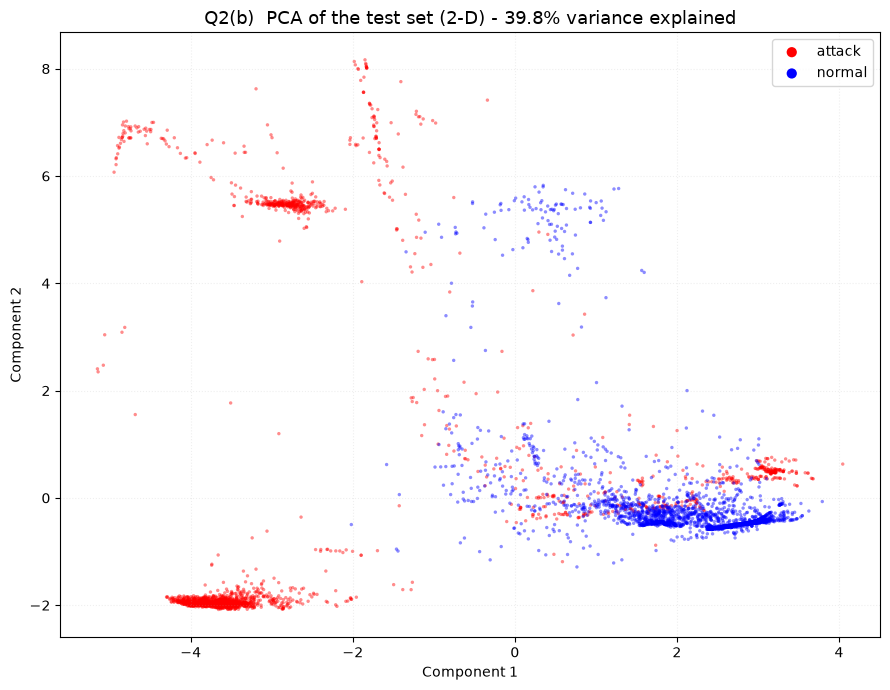

In [12]:
from sklearn.decomposition import PCA
# ===== Question 2(b): PCA ====================================================

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_viz)

evr = pca.explained_variance_ratio_
print(f"Explained variance  PC1 = {evr[0]:.4f}   PC2 = {evr[1]:.4f}   "
      f"total = {evr.sum():.4f}")

plot_2d(X_pca, y_viz,
        f"Q2(b)  PCA of the test set (2-D) - {evr.sum()*100:.1f}% variance explained",
        "q2b_pca.png")


##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

KernelPCA (rbf) finished in 0.6 s


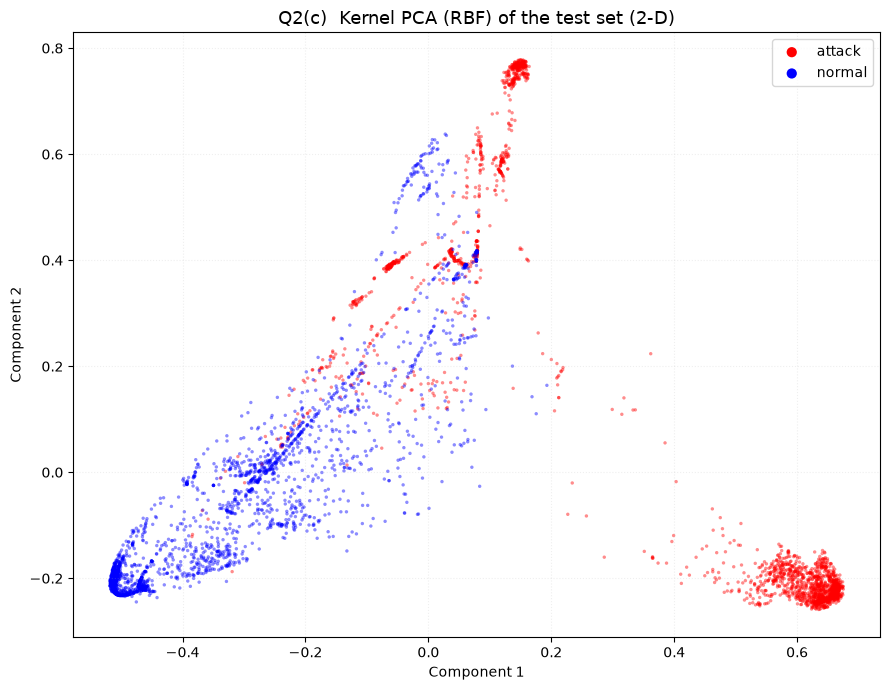

In [13]:
from sklearn.decomposition import KernelPCA
# ===== Question 2(c): Kernel PCA with an RBF kernel ==========================
import time

t0 = time.time()
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=None, random_state=SEED)
X_kpca = kpca.fit_transform(X_viz)
print(f"KernelPCA (rbf) finished in {time.time()-t0:.1f} s")

plot_2d(X_kpca, y_viz,
        "Q2(c)  Kernel PCA (RBF) of the test set (2-D)",
        "q2c_kernelpca.png")


## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure that the output layer contains one neuron with sigmoid activation.

In [14]:
# ===== Question 3(a): define the DNN ========================================
# Kept deliberately small: the Arduino Nano 33 BLE sketch allocates a 32 KB
# tensor arena (TENSOR_ARENA_SIZE in network_data.ino), so the weights plus all
# intermediate activations have to fit comfortably inside that budget.
# Output layer = 1 neuron + sigmoid, as required.

# Define the DNN model
base_model = Sequential([
    Input(shape=(N_FEATURES,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

base_model.summary()


Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 64)                2496      


 dense_1 (Dense)             (None, 32)                2080      


...

 dense_3 (Dense)             (None, 1)                 17        


Total params: 5121 (20.00 KB)


Trainable params: 5121 (20.00 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

Epoch 1/20


355/355 - 1s - loss: 0.1108 - accuracy: 0.9676 - val_loss: 0.0169 - val_accuracy: 0.9946 - 902ms/epoch - 3ms/step


Epoch 2/20


355/355 - 0s - loss: 0.0128 - accuracy: 0.9953 - val_loss: 0.0101 - val_accuracy: 0.9958 - 324ms/epoch - 912us/step


Epoch 3/20


...

355/355 - 0s - loss: 0.0027 - accuracy: 0.9991 - val_loss: 0.0042 - val_accuracy: 0.9989 - 384ms/epoch - 1ms/step


Epoch 19/20


355/355 - 0s - loss: 0.0025 - accuracy: 0.9990 - val_loss: 0.0060 - val_accuracy: 0.9986 - 322ms/epoch - 908us/step


Epoch 20/20


355/355 - 0s - loss: 0.0023 - accuracy: 0.9992 - val_loss: 0.0044 - val_accuracy: 0.9989 - 324ms/epoch - 913us/step


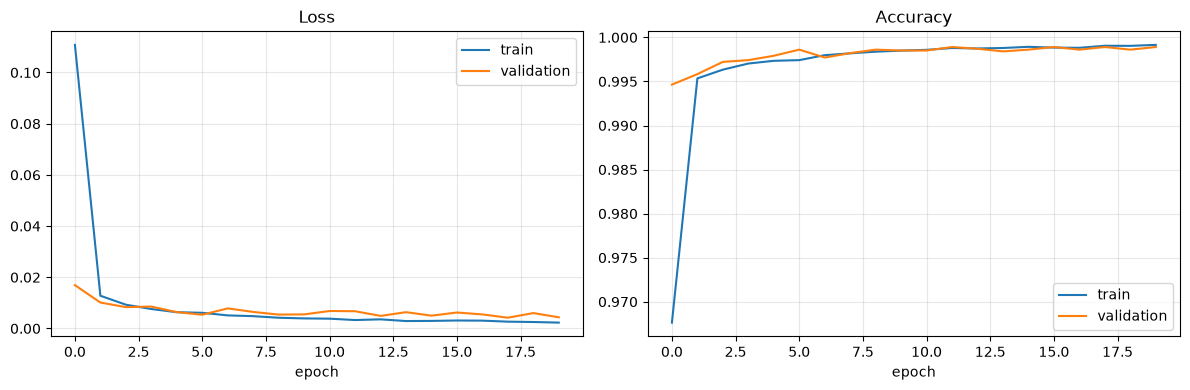

In [15]:
# ===== Question 3(b): compile and train =====================================

base_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history = base_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=2,
)

# Training curves (handy for the writeup, not required by the assignment)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='validation')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(history.history['accuracy'], label='train')
ax[1].plot(history.history['val_accuracy'], label='validation')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(join("writeup_assets", "q3b_training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()


##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Q3(c)  FLOAT32 base_model - test set performance
Accuracy: 0.9985

Classification report:

              precision    recall  f1-score   support

  attack (0)     0.9984    0.9985    0.9984     11726
  normal (1)     0.9987    0.9986    0.9986     13469

    accuracy                         0.9985     25195
   macro avg     0.9985    0.9985    0.9985     25195
weighted avg     0.9985    0.9985    0.9985     25195

Confusion matrix (rows = actual, cols = predicted):

[[11708    18]
 [   19 13450]]


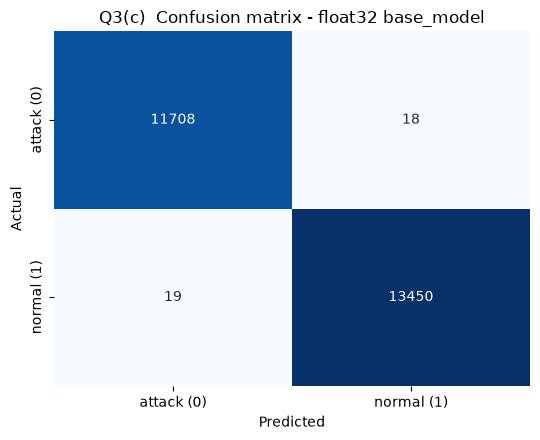

In [16]:
# ===== Question 3(c): evaluate base_model on the test set ===================

y_prob_base = base_model.predict(X_test, verbose=0).ravel()
y_pred_base = (y_prob_base > 0.5).astype(int)
y_true = y_test.ravel()

target_names = ['attack (0)', 'normal (1)']

report_base = classification_report(y_true, y_pred_base,
                                    target_names=target_names, digits=4)
cm_base = confusion_matrix(y_true, y_pred_base)
acc_base = accuracy_score(y_true, y_pred_base)

print("=" * 62)
print("Q3(c)  FLOAT32 base_model - test set performance")
print("=" * 62)
print(f"Accuracy: {acc_base:.4f}\n")
print("Classification report:\n")
print(report_base)
print("Confusion matrix (rows = actual, cols = predicted):\n")
print(cm_base)

# Save the text so the .pdf writeup can quote exact numbers
with open(join("writeup_assets", "q3c_base_model_report.txt"), "w") as f:
    f.write("Q3(c)  FLOAT32 base_model - test set performance\n")
    f.write(f"Accuracy: {acc_base:.4f}\n\n")
    f.write(report_base + "\n")
    f.write("Confusion matrix (rows = actual, cols = predicted):\n")
    f.write(str(cm_base) + "\n")

# Heat-map version of the confusion matrix
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names, yticklabels=target_names)
plt.title("Q3(c)  Confusion matrix - float32 base_model")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(join("writeup_assets", "q3c_confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement full-integer INT8 post-training quantization on the base_model. Use a representative dataset from X_train to calibrate the activation ranges. Configure the converter to use INT8 operators with INT8 input and output tensors. Designate the resulting quantized model as tflite_quant_model.

In [18]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

# ===== Question 4(a): full-integer INT8 post-training quantization ==========
# A representative dataset lets the converter observe real activation ranges so
# it can pick per-tensor scale/zero-point values. Without it, only the weights
# would be quantized and the activations would stay float.

REPRESENTATIVE_SAMPLES = 500

def representative_data_gen():
    """Yield single float32 samples drawn from the training set."""
    for i in range(REPRESENTATIVE_SAMPLES):
        yield [X_train[i:i + 1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Force INT8 kernels only, plus INT8 input and output tensors, so the model that
# lands on the microcontroller never touches a float operator.
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

# Confirm the resulting tensor types and record the quantization parameters --
# the Arduino sketch needs input scale/zero-point to quantize its samples.
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]

print("Input  tensor:", inp['dtype'].__name__, inp['shape'],
      "scale=%.10f zero_point=%d" % (inp['quantization'][0], inp['quantization'][1]))
print("Output tensor:", out['dtype'].__name__, out['shape'],
      "scale=%.10f zero_point=%d" % (out['quantization'][0], out['quantization'][1]))
assert inp['dtype'] == np.int8 and out['dtype'] == np.int8, "input/output must be INT8"
print("\nFull-integer INT8 quantization OK.")


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpnozr_l5z/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpnozr_l5z/assets


2026-08-11 00:05:00.100661: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.


Input  tensor: int8 [ 1 38] scale=0.0895969868 zero_point=-52
Output tensor: int8 [1 1] scale=0.0039062500 zero_point=-128

Full-integer INT8 quantization OK.


2026-08-11 00:05:00.100678: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-08-11 00:05:00.101195: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpnozr_l5z
2026-08-11 00:05:00.102168: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-08-11 00:05:00.102177: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpnozr_l5z
2026-08-11 00:05:00.104538: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-08-11 00:05:00.105763: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-08-11 00:05:00.159424: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpnozr_l5z

In [19]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 100.01 KB
Quantized model size: 8.24 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

input  scale = 0.0895969868   zero_point = -52
output scale = 0.0039062500   zero_point = -128



Q4(b)  INT8 tflite_quant_model - test set performance
Accuracy: 0.9984

Classification report:

              precision    recall  f1-score   support

  attack (0)     0.9979    0.9987    0.9983     11726
  normal (1)     0.9989    0.9981    0.9985     13469

    accuracy                         0.9984     25195
   macro avg     0.9984    0.9984    0.9984     25195
weighted avg     0.9984    0.9984    0.9984     25195

Confusion matrix (rows = actual, cols = predicted):

[[11711    15]
 [   25 13444]]

--------------------------------------------------------------
float32 base_model      accuracy : 0.9985
INT8    quantized model accuracy : 0.9984
accuracy change                  : -0.0001
model size reduction             : 12.13x smaller
--------------------------------------------------------------


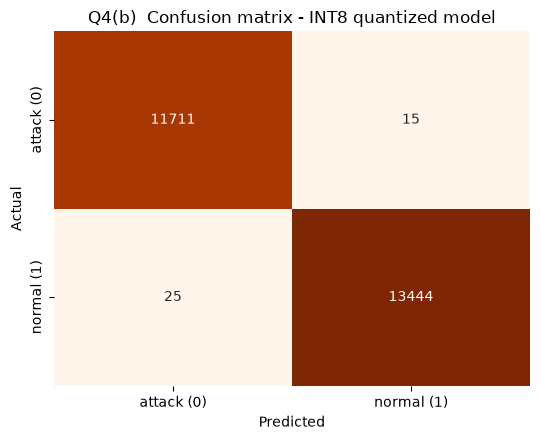

In [20]:
# ===== Question 4(b): evaluate tflite_quant_model on the test set ===========
# Each sample is quantized with the INPUT tensor's own scale/zero-point before
# inference, and the INT8 result is dequantized with the OUTPUT tensor's
# scale/zero-point to recover the sigmoid probability. This mirrors exactly what
# quantize_to_int8() does inside network_data.ino.

interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

in_scale,  in_zero_point  = input_details['quantization']
out_scale, out_zero_point = output_details['quantization']

print(f"input  scale = {in_scale:.10f}   zero_point = {in_zero_point}")
print(f"output scale = {out_scale:.10f}   zero_point = {out_zero_point}\n")

in_index  = input_details['index']
out_index = output_details['index']

y_prob_quant = np.zeros(len(X_test), dtype=np.float32)

for i in range(len(X_test)):
    # float -> int8 using the input tensor's quantization parameters
    x_q = np.round(X_test[i] / in_scale + in_zero_point)
    x_q = np.clip(x_q, -128, 127).astype(np.int8).reshape(input_details['shape'])

    interpreter.set_tensor(in_index, x_q)
    interpreter.invoke()

    # int8 -> float using the output tensor's quantization parameters
    y_q = interpreter.get_tensor(out_index)[0][0]
    y_prob_quant[i] = (float(y_q) - out_zero_point) * out_scale

y_pred_quant = (y_prob_quant > 0.5).astype(int)

report_quant = classification_report(y_true, y_pred_quant,
                                     target_names=target_names, digits=4)
cm_quant = confusion_matrix(y_true, y_pred_quant)
acc_quant = accuracy_score(y_true, y_pred_quant)

print("=" * 62)
print("Q4(b)  INT8 tflite_quant_model - test set performance")
print("=" * 62)
print(f"Accuracy: {acc_quant:.4f}\n")
print("Classification report:\n")
print(report_quant)
print("Confusion matrix (rows = actual, cols = predicted):\n")
print(cm_quant)

print("\n" + "-" * 62)
print(f"float32 base_model      accuracy : {acc_base:.4f}")
print(f"INT8    quantized model accuracy : {acc_quant:.4f}")
print(f"accuracy change                  : {acc_quant - acc_base:+.4f}")
print(f"model size reduction             : "
      f"{original_model_size/quantized_model_size:.2f}x smaller")
print("-" * 62)

with open(join("writeup_assets", "q4b_quantized_model_report.txt"), "w") as f:
    f.write("Q4(b)  INT8 tflite_quant_model - test set performance\n")
    f.write(f"input  scale = {in_scale:.10f}  zero_point = {in_zero_point}\n")
    f.write(f"output scale = {out_scale:.10f}  zero_point = {out_zero_point}\n\n")
    f.write(f"Accuracy: {acc_quant:.4f}\n\n")
    f.write(report_quant + "\n")
    f.write("Confusion matrix (rows = actual, cols = predicted):\n")
    f.write(str(cm_quant) + "\n\n")
    f.write(f"float32 accuracy : {acc_base:.4f}\n")
    f.write(f"INT8    accuracy : {acc_quant:.4f}\n")
    f.write(f"change           : {acc_quant - acc_base:+.4f}\n")

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_quant, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=target_names, yticklabels=target_names)
plt.title("Q4(b)  Confusion matrix - INT8 quantized model")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(join("writeup_assets", "q4b_confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()


## Converting tflite_quant_model to C and creating the header file

In [21]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [22]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [23]:
# ===== Question 5(c): first FIVE test samples for network_data.ino ==========
# Converting a sample piece of the X test and y test data to C (for the purpose
# of ino code (arduino) to load and test the sample and compare.

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))


const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -2.468724163053645, -0.9926628603286901, 
    0.7511112872365361, -0.007586440761970732, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    3.7280528465157605, 6.65324490222183, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, -0.37455970440553465, 
    0.7343425609306344, 0.3915636300872831, 0.21997736341067137, 
    -0.33321384013747096, 1.5263022423334498, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, -0.6563667617603728, -0.110249223212498

In [24]:
# y_test is stored as an (n, 1) column vector; .ravel() flattens it so c_writer
# emits `y_test[5]` rather than `y_test[5][1]`, matching the declaration in
# network_data.ino.
ytest = y_test[0:5].ravel()
print(c_writer.create_array(ytest,"uint8_t","y_test"))


const unsigned int y_test_dim1 = 5;

const uint8_t y_test[5] = {
    0, 1, 1, 0, 0
};



In [25]:
# ===== Question 5(d): the NEXT TEN test samples ============================
# "10 features and actual labels of the test set excluding the first five
# samples" -> rows 5..14 of X_test, i.e. the ten samples that follow the five
# used in part (c). These arrays go into the part (d) copy of the sketch.

Xtest_10 = X_test[5:15,:]
print(c_writer.create_array(Xtest_10,"float","X_test"))


const unsigned int X_test_dim1 = 10;
const unsigned int X_test_dim2 = 38;

const float X_test[10][38] = {
    -0.11024922321249885, -0.12470615670462065, 1.0873051789289023, 
    -2.2235805674567635, -0.00776224074056876, -0.004918644383724874, 
    -0.08948642202040107, -0.09507567152556495, -0.8092618187059747, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.7170454919159579, -0.3681102129968653, -0.6372092679572258, 
    -0.6319290328885425, 2.7464027950834815, 2.715364578035608, 
    -0.36605989270614575, 5.196207521885405, -0.37455970440553465, 
    0.7343425609306344, -1.0356876376568842, -1.161030186584037, 
    2.1545978667566934, 1.040858914144111, -0.28910340026287856, 
    -0.6395319051152512, -0.6248707997445304, 1.1781465787299172, 
    2.753913722653446, -0.21997021516886575, -0.11024922321249885,

In [26]:
ytest_10 = y_test[5:15].ravel()
print(c_writer.create_array(ytest_10,"uint8_t","y_test"))


const unsigned int y_test_dim1 = 10;

const uint8_t y_test[10] = {
    0, 1, 0, 1, 0, 0, 0, 1, 0, 1
};



In [27]:
# ===== Reference values for the Arduino sketch =============================
# Expected on-device predictions, so the Serial Monitor output can be checked
# against the desktop interpreter.

def tflite_predict(rows):
    out = []
    for r in rows:
        x_q = np.round(r / in_scale + in_zero_point)
        x_q = np.clip(x_q, -128, 127).astype(np.int8).reshape(input_details['shape'])
        interpreter.set_tensor(in_index, x_q)
        interpreter.invoke()
        y_q = interpreter.get_tensor(out_index)[0][0]
        out.append((float(y_q) - out_zero_point) * out_scale)
    return np.array(out)

print("Quantization parameters used by network_data.ino")
print(f"  input  scale = {in_scale:.10f}   zero_point = {in_zero_point}")
print(f"  output scale = {out_scale:.10f}   zero_point = {out_zero_point}\n")

for tag, xs, ys, offset in [("Q5(c) samples 0-4",  X_test[0:5],  y_test[0:5].ravel(),  0),
                            ("Q5(d) samples 5-14", X_test[5:15], y_test[5:15].ravel(), 5)]:
    probs = tflite_predict(xs)
    print(tag)
    print(f"  {'Sample':>6} {'Prob':>9} {'Predicted':>10} {'Actual':>8}")
    for i, (p, a) in enumerate(zip(probs, ys)):
        print(f"  {offset+i:>6} {p:>9.4f} {int(p > 0.5):>10} {int(a):>8}")
    print(f"  agreement: {(  (probs > 0.5).astype(int) == ys).sum()}/{len(ys)}\n")

with open(join("writeup_assets", "q5_expected_predictions.txt"), "w") as f:
    f.write("Expected predictions from the desktop INT8 interpreter\n")
    f.write(f"input  scale={in_scale:.10f} zero_point={in_zero_point}\n")
    f.write(f"output scale={out_scale:.10f} zero_point={out_zero_point}\n\n")
    for tag, xs, ys, offset in [("Q5(c) samples 0-4",  X_test[0:5],  y_test[0:5].ravel(),  0),
                                ("Q5(d) samples 5-14", X_test[5:15], y_test[5:15].ravel(), 5)]:
        probs = tflite_predict(xs)
        f.write(tag + "\n")
        for i, (p, a) in enumerate(zip(probs, ys)):
            f.write(f"  Sample {offset+i}: prob={p:.4f} predicted={int(p>0.5)} actual={int(a)}\n")
        f.write("\n")


Quantization parameters used by network_data.ino
  input  scale = 0.0895969868   zero_point = -52
  output scale = 0.0039062500   zero_point = -128

Q5(c) samples 0-4
  Sample      Prob  Predicted   Actual
       0    0.0000          0        0
       1    0.9961          1        1
       2    0.9961          1        1
       3    0.0000          0        0
       4    0.0000          0        0
  agreement: 5/5

Q5(d) samples 5-14
  Sample      Prob  Predicted   Actual
       5    0.0000          0        0
       6    0.9961          1        1
       7    0.0000          0        0
       8    0.9961          1        1
       9    0.0000          0        0
      10    0.0000          0        0
      11    0.0000          0        0
      12    0.9961          1        1
      13    0.0000          0        0
      14    0.9961          1        1
  agreement: 10/10

